# Test classes for training the agent

In [1]:
import sys

sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from agents.agentsCS import AgentCS
from agents.linearQ import TilesQ
from utils.interpreters import gym_interpreter1
from utils.interaction import Episode
from utils.performer import Performer
from environments.foragers import DiscreteForagersEnv

In [2]:
num_actions = 11
env = DiscreteForagersEnv(
    initial_rate=0.5,
    initial_wealth=1.0,
    num_foragers=3,
    num_discrete_actions=num_actions
)
env.render()

Turn=0 --- State=[0.5 1. ] --- Manager budget=0.10 --- Forager budget=0.10


In [3]:
state_scales = [
    {'min':0.0, 'max':1.0},
    {'min':0.0, 'max':1.0},
]
tiles_parameters = {
    'numDims': 2,
    'numTilings': 8,
    'numTiles': [8, 8],
    'scaleFactors':state_scales,
    'maxSize':4096,
    'alpha':0.1,
    'num_actions': num_actions
}
value_approximator = TilesQ(parameters=tiles_parameters)
agent_parameters = {
    'nA':num_actions,
    'nS':2,
    'gamma':1,
    'epsilon':0,
    'alpha':0.1,
    'Q':value_approximator
}
agent = AgentCS(
    parameters=agent_parameters
)

In [4]:
episode = Episode(
    environment=env,
    env_name="Foragers",
    agent=agent,
    model_name="TilesQ",
    num_rounds=10,
    state_interpreter=gym_interpreter1,
)

In [5]:
episode.play_round(verbose=5)

	The state is => [0.5 0. ]
	Agent takes action => 10
	The state obtained is => [1.  0.5]
	The reward obtained is => 0.4911111111111111
	Environment is finished? => False
	Environment is truncated? => False


In [6]:
perf = Performer(
    env_name='DiscreteForagersEnv',
    env_parameters={},
    state_interpreter=gym_interpreter1,
    agent_name='agentsCS.QLearningCS',
    agent_parameters=agent_parameters
)
agent_path = perf.file_model
agent.load(agent_path)

In [7]:
episode.run(verbose=0, learn=False)

,model,environment,episode,round,state,action,reward,done
0,TilesQ,Foragers,0,0,"[0.5, 0.5]",7,0.704219,False
1,TilesQ,Foragers,0,1,"[0.7, 0.7375]",8,0.690664,False
2,TilesQ,Foragers,0,2,"[0.8, 0.725]",7,0.811424,False
3,TilesQ,Foragers,0,3,"[0.7, 0.83750004]",3,0.982222,False
4,TilesQ,Foragers,0,4,"[0.3, 1.0]",4,0.982222,False
5,TilesQ,Foragers,0,5,"[0.4, 1.0]",10,0.908104,False
6,TilesQ,Foragers,0,6,"[1.0, 0.9125]",5,0.982222,False
7,TilesQ,Foragers,0,7,"[0.5, 1.0]",7,0.982222,False
8,TilesQ,Foragers,0,8,"[0.7, 1.0]",8,0.908104,False
9,TilesQ,Foragers,0,9,"[0.8, 0.9125]",5,0.982222,False


In [16]:
list_df = []
for _ in range(100):
    df = episode.run(verbose=0, learn=False)
    df['inequality'] = episode.environment.inequalities
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)
df["rate"] = df['state'].apply(lambda x: x[0])
df["wealth"] = df['state'].apply(lambda x: x[1])
df["initial_wealth"] = df.loc[0, "state"][1]

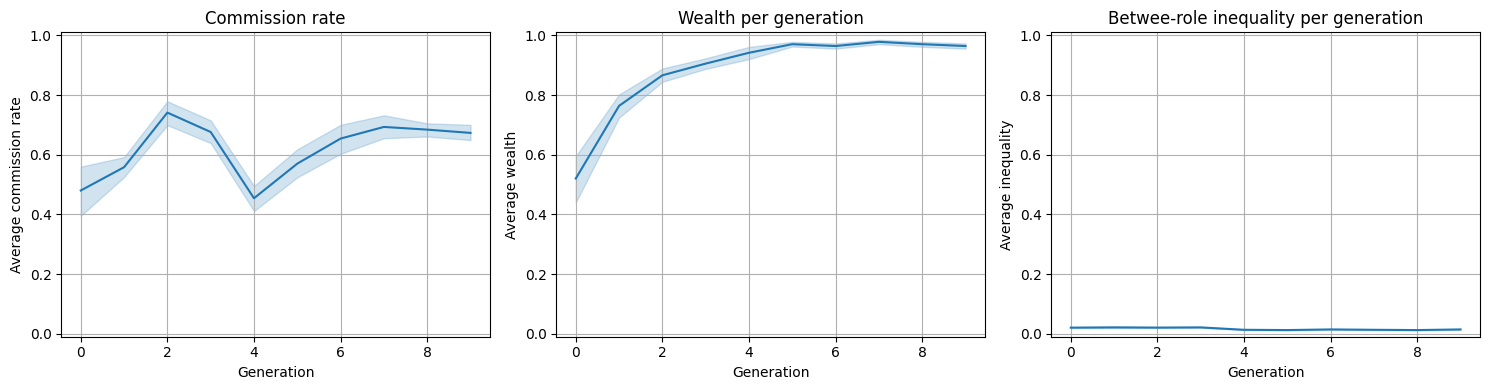

In [19]:
fig, axes = plt.subplots(
    1, 3, 
    figsize=(15,4), 
    tight_layout=True,
    sharex=True,
    sharey=False,
)
sns.lineplot(
    data=df,
    x='round',
    y='rate',
    ax=axes[0],
)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Average commission rate")
axes[0].set_title("Commission rate")
sns.lineplot(
    data=df,
    x='round',
    y='wealth',
    ax=axes[1]
)
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Average wealth")
axes[1].set_title("Wealth per generation")
sns.lineplot(
    data=df,
    x='round',
    y='inequality',
    ax=axes[2]
)
axes[2].set_xlabel("Generation")
axes[2].set_ylabel("Average inequality")
axes[2].set_title("Betwee-role inequality per generation")

for ax in axes:
    ax.grid()
    ax.set_ylim([-.01, 1.01])

In [9]:
fig.savefig('best_training.png', dpi=300)